# 07 — PCA & K-Means Clustering
Grouping countries by vaccination + socioeconomic profile.

In [1]:
import pickle
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120

OUT = os.path.join("..", "outputs")
os.makedirs(OUT, exist_ok=True)

In [2]:
with open(os.path.join("..", "data", "processed.pkl"), "rb") as f:
    df = pickle.load(f)

df["date"] = pd.to_datetime(df["date"])

# pull socioeconomic features from main OWID dataset
owid_url = "https://raw.githubusercontent.com/owid/covid-19-data/master/public/data/owid-covid-data.csv"
meta_cols = ["location", "gdp_per_capita", "population_density",
             "median_age", "aged_65_older", "human_development_index", "life_expectancy"]
print("Fetching OWID metadata...")
meta = pd.read_csv(owid_url, usecols=meta_cols).groupby("location").first().reset_index()
print(f"Done — {len(meta)} locations")

Fetching OWID metadata...


Done — 255 locations


## 1. Prepare feature matrix

In [3]:
latest = df.sort_values("date").groupby("location").last().reset_index()
latest = latest.merge(meta, on="location", how="left")

features = [
    "people_fully_vaccinated_per_hundred", "total_boosters_per_hundred",
    "gdp_per_capita", "population_density",
    "median_age", "aged_65_older", "human_development_index", "life_expectancy"
]

X_raw = latest[features].copy()

# impute missing with column median
for col in features:
    X_raw[col] = X_raw[col].fillna(X_raw[col].median())

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)
print(f"Feature matrix: {X.shape}")

Feature matrix: (221, 8)


## 2. Elbow method

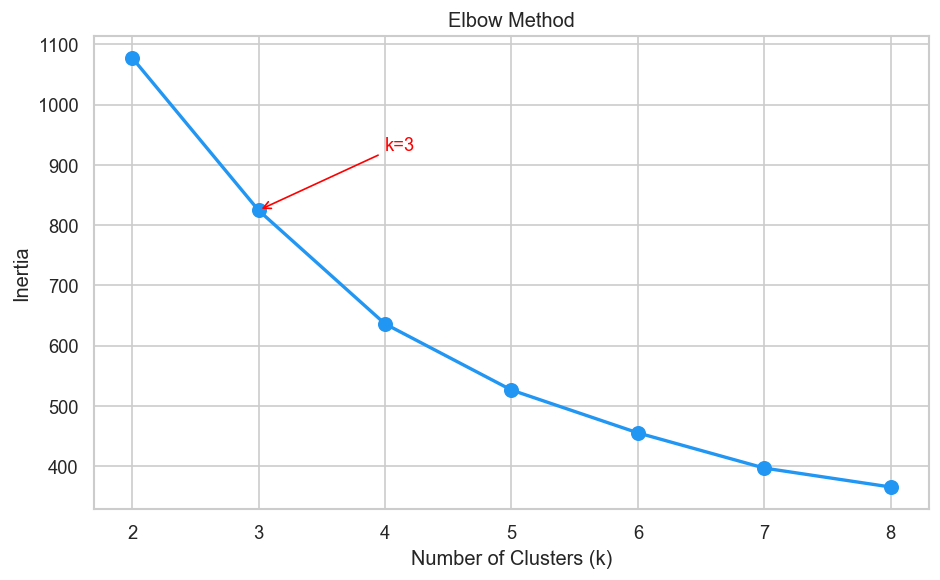

In [4]:
K_range = range(2, 9)
inertias = []
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    km.fit(X)
    inertias.append(km.inertia_)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(list(K_range), inertias, "o-", color="#2196F3", linewidth=2, markersize=8)
ax.set_xlabel("Number of Clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow Method")
ax.set_xticks(list(K_range))

# mark k=3 as the elbow
ax.annotate("k=3", xy=(3, inertias[1]), xytext=(4, inertias[1] + 100),
            arrowprops=dict(arrowstyle="->", color="red"), fontsize=11, color="red")

fig.tight_layout()
fig.savefig(os.path.join(OUT, "elbow_method.png"))
plt.show()

## 3. KMeans with k=3

In [5]:
km = KMeans(n_clusters=3, n_init=10, random_state=42)
latest["cluster"] = km.fit_predict(X)
print(latest["cluster"].value_counts().sort_index())

cluster
0    114
1     56
2     51
Name: count, dtype: int64


## 4. PCA — explained variance

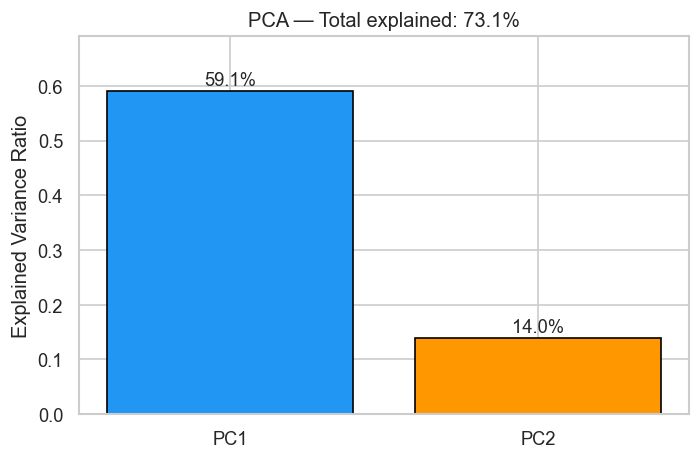

In [6]:
pca = PCA(n_components=2, random_state=42)
pcs = pca.fit_transform(X)
latest["PC1"] = pcs[:, 0]
latest["PC2"] = pcs[:, 1]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["PC1", "PC2"], pca.explained_variance_ratio_,
              color=["#2196F3", "#FF9800"], edgecolor="black")
for bar, val in zip(bars, pca.explained_variance_ratio_):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.1%}", ha="center", fontsize=11)

ax.set_ylabel("Explained Variance Ratio")
ax.set_title(f"PCA — Total explained: {pca.explained_variance_ratio_.sum():.1%}")
ax.set_ylim(0, max(pca.explained_variance_ratio_) + 0.1)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "pca_variance.png"))
plt.show()

## 5. PCA scatter — colored by cluster

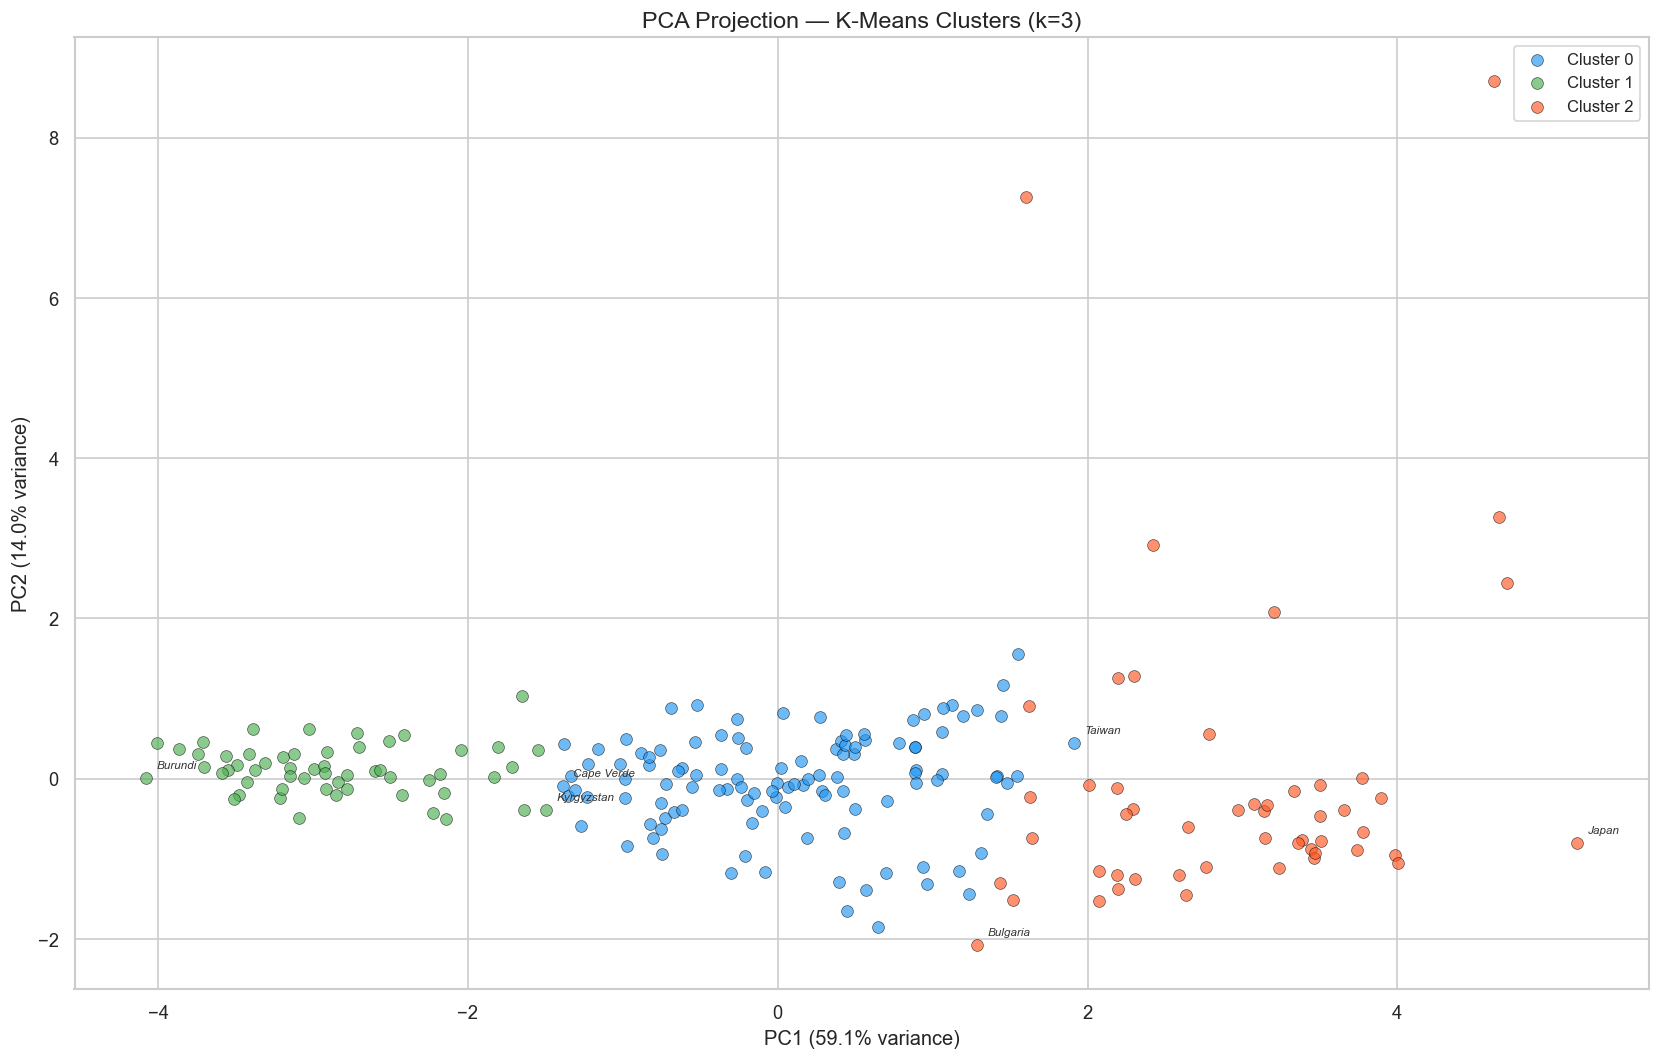

In [7]:
cluster_colors = {0: "#2196F3", 1: "#4CAF50", 2: "#FF5722"}
cluster_names = {0: "Cluster 0", 1: "Cluster 1", 2: "Cluster 2"}

fig, ax = plt.subplots(figsize=(14, 9))
for c in sorted(latest["cluster"].unique()):
    chunk = latest[latest["cluster"] == c]
    ax.scatter(chunk["PC1"], chunk["PC2"], label=cluster_names[c],
              color=cluster_colors[c], alpha=0.65, s=50, edgecolors="black", linewidth=0.4)

# annotate interesting countries: highest and lowest PC1 per cluster
for c in sorted(latest["cluster"].unique()):
    chunk = latest[latest["cluster"] == c]
    for idx in [chunk["PC1"].idxmax(), chunk["PC1"].idxmin()]:
        row = latest.loc[idx]
        ax.annotate(row["location"], xy=(row["PC1"], row["PC2"]),
                    xytext=(6, 6), textcoords="offset points",
                    fontsize=7, fontstyle="italic", color="#333")

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
ax.set_title("PCA Projection — K-Means Clusters (k=3)", fontsize=14)
ax.legend(fontsize=10)
fig.tight_layout()
fig.savefig(os.path.join(OUT, "pca_clusters.png"))
plt.show()

## 6. Cluster profiles

In [8]:
profiles = latest.groupby("cluster")[features].mean().round(2)

# auto-generate cluster descriptions based on relative values
for c in sorted(profiles.index):
    row = profiles.loc[c]
    vacc = row["people_fully_vaccinated_per_hundred"]
    gdp = row["gdp_per_capita"]
    hdi = row["human_development_index"]

    # simple heuristic labels
    if vacc > 65 and gdp > 30000:
        desc = "High income, high vaccination coverage countries"
    elif vacc > 50 and hdi > 0.7:
        desc = "Middle-to-upper income, moderate-high vaccination coverage"
    elif vacc < 40:
        desc = "Lower income, lower vaccination coverage countries"
    else:
        desc = "Mixed-income, moderate vaccination coverage"

    countries = latest[latest["cluster"] == c]["location"].tolist()
    print(f"\n{'='*70}")
    print(f"CLUSTER {c}: {desc}")
    print(f"{'='*70}")
    print(f"  Countries ({len(countries)}): {', '.join(sorted(countries))}")
    print(f"  Mean fully vaccinated %:  {vacc:.1f}")
    print(f"  Mean GDP per capita:      ${gdp:,.0f}")
    print(f"  Mean HDI:                 {hdi:.3f}")
    print(f"  Mean median age:          {row['median_age']:.1f}")
    print(f"  Mean life expectancy:     {row['life_expectancy']:.1f}")


CLUSTER 0: Middle-to-upper income, moderate-high vaccination coverage
  Countries (114): Albania, Algeria, Andorra, Anguilla, Antigua and Barbuda, Argentina, Armenia, Azerbaijan, Bahamas, Bahrain, Bangladesh, Barbados, Belize, Bermuda, Bhutan, Bolivia, Bonaire Sint Eustatius and Saba, Bosnia and Herzegovina, Botswana, Brazil, British Virgin Islands, Cambodia, Cape Verde, Cayman Islands, China, Colombia, Cook Islands, Costa Rica, Curacao, Dominica, Dominican Republic, Ecuador, Egypt, El Salvador, England, Faeroe Islands, Falkland Islands, Fiji, French Polynesia, Georgia, Greenland, Grenada, Guatemala, Guernsey, Guyana, Honduras, India, Indonesia, Iran, Isle of Man, Jamaica, Jersey, Jordan, Kazakhstan, Kosovo, Kuwait, Laos, Lebanon, Libya, Malaysia, Maldives, Mauritius, Mexico, Moldova, Mongolia, Montenegro, Montserrat, Morocco, Myanmar, Nauru, Nepal, New Caledonia, Nicaragua, Niue, North Macedonia, Northern Cyprus, Northern Ireland, Oman, Panama, Paraguay, Peru, Philippines, Pitcairn, 

## 7. Silhouette score

In [9]:
sil = silhouette_score(X, latest["cluster"])
print(f"Silhouette Score (k=3): {sil:.4f}")
if sil > 0.5:
    print("  → Good cluster separation")
elif sil > 0.25:
    print("  → Reasonable structure, some overlap")
else:
    print("  → Weak structure, clusters overlap significantly")

Silhouette Score (k=3): 0.3418
  → Reasonable structure, some overlap
